**Import packages**

In [ ]:
# Numerical Operations
import math
import numpy as np

# Progress bar
from tqdm import tqdm

# Pytorch
import torch
import torch.optim as optim

# Plotting learning curve
from matplotlib import pyplot as plt

**Dataset**

Text(0, 0.5, 'z height (m)')

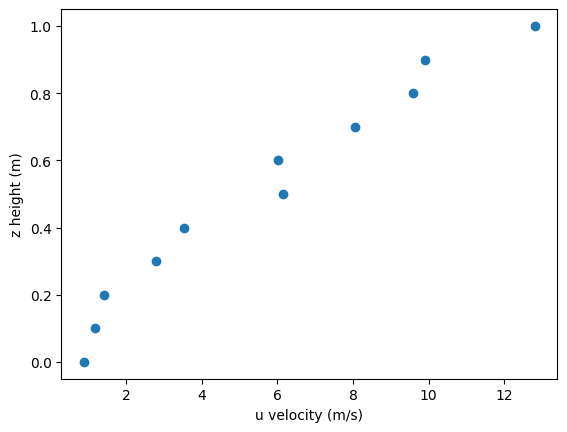

In [ ]:
#Linear Couette flow
H=1
z=np.arange(0,1.1,0.1)
U=10
u=z*U/H+np.random.randn(len(z))
plt.scatter(u,z)
plt.xlabel("u velocity (m/s)")
plt.ylabel("z height (m)")

In [ ]:
#Put datas into torch tensor
z=torch.tensor(z)
u=torch.tensor(u)
'''advanced level'''
data=list(zip(z, u))

**Model**

In [ ]:
#Linear model
def model(x,w,b):
    return w*x+b

**Loss function**

In [ ]:
#Mean Square Error Loss
def loss_fn(x_p,y):
    loss_fn=(x_p-y)**2
    return loss_fn.mean()

**Derivative of loss function**

In [ ]:
#Taking derivative by calculus
def grad_fn(x_p,x,y):
    dloss_dw=2*(x_p-y)*x
    dloss_db=2*(x_p-y)*1.0
    return torch.stack([dloss_dw.mean(), dloss_db.mean()])

**Optimizer**

In [ ]:
#Gradient descent
def gradient_descent(params,lr,grad):
    params=params-lr*grad
    return params

**Training loop**

In [ ]:
#Parameters update
def training(train_data,val_data,params,n_epoch,lr,patience):
    w, b=params

    '''intermediate level'''
    optimizer=optim.SGD([w, b], lr=lr, weight_decay=0.001)

    '''advanced level'''
    best_val_loss=float('inf')
    epochs_no_improve=0

    for epoch in range(1, n_epoch+1):
        # training set
        train_z,train_u=zip(*train_data)
        train_u=torch.tensor(train_u)
        train_z=torch.tensor(train_z)

        x_p_train=model(train_z,w,b)
        train_loss=loss_fn(x_p_train,train_u)

        # validation set
        val_z,val_u=zip(*val_data)
        val_u=torch.tensor(val_u)
        val_z=torch.tensor(val_z)

        x_p_val=model(val_z,w,b)
        val_loss=loss_fn(x_p_val,val_u)

        '''intermediate level'''
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        '''advanced level'''
        if epoch%10==0:
          print(f'Epoch:{epoch}, Training Loss:{train_loss.item():.4f}, Validation Loss:{val_loss.item():.4f}')

        if val_loss < best_val_loss:
          best_val_loss=val_loss
          epochs_no_improve=0
        else:
          epochs_no_improve=epochs_no_improve+1

        if epochs_no_improve >= patience:
          print(f'--------------------------------------------------------\nEarly stopping at epoch {epoch}')
          break

    return params

**Dataset splitting**

In [ ]:
'''advanced level'''
data_size=len(data)
train_size=int(0.8*data_size)
val_size=data_size-train_size

train_data, val_data=torch.utils.data.random_split(data, [train_size, val_size])

**Configuration**

In [ ]:
'''basic level'''
params=[torch.tensor(15.0, requires_grad=True), torch.tensor(8.0, requires_grad=True)]
config={
    "number epoch": 3000, # number of epoch, suggest from 100 to 50000
    "learning rate": 0.001, # learning rate, suggest from 1e-2 to 1e-5
    "patience": 10, # Early Stopping's parameter
    }

**Training !**

In [ ]:
params=training(train_data,val_data,params,config["number epoch"],config["learning rate"],config["patience"])

Epoch:10, Training Loss:96.4483, Validation Loss:86.6683
Epoch:20, Training Loss:91.6610, Validation Loss:82.1831
Epoch:30, Training Loss:87.1133, Validation Loss:77.9265
Epoch:40, Training Loss:82.7932, Validation Loss:73.8869
Epoch:50, Training Loss:78.6892, Validation Loss:70.0533
Epoch:60, Training Loss:74.7907, Validation Loss:66.4153
Epoch:70, Training Loss:71.0872, Validation Loss:62.9631
Epoch:80, Training Loss:67.5691, Validation Loss:59.6873
Epoch:90, Training Loss:64.2270, Validation Loss:56.5789
Epoch:100, Training Loss:61.0521, Validation Loss:53.6295
Epoch:110, Training Loss:58.0362, Validation Loss:50.8310
Epoch:120, Training Loss:55.1711, Validation Loss:48.1759
Epoch:130, Training Loss:52.4494, Validation Loss:45.6567
Epoch:140, Training Loss:49.8639, Validation Loss:43.2668
Epoch:150, Training Loss:47.4078, Validation Loss:40.9994
Epoch:160, Training Loss:45.0745, Validation Loss:38.8485
Epoch:170, Training Loss:42.8580, Validation Loss:36.8080
Epoch:180, Training Los

**Plot the result**

Text(0, 0.5, 'z height (m)')

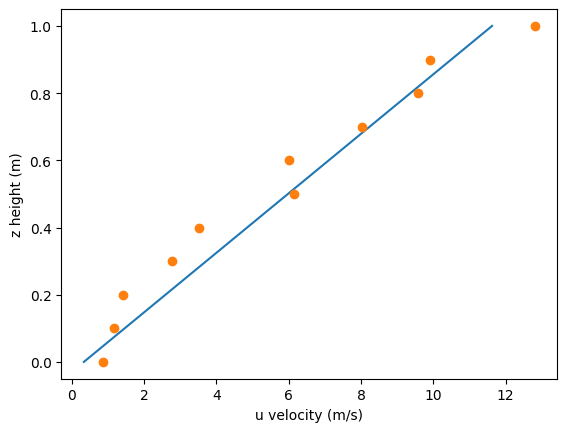

In [ ]:
w,b=params
z_p=model(z,w,b)
fig=plt.figure(dpi=100)
plt.plot(z_p.detach().numpy(),z.detach().numpy())
plt.plot(u.numpy(),z.numpy(), 'o')
plt.xlabel("u velocity (m/s)")
plt.ylabel("z height (m)")